<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4907---NLU/blob/main/(GWU)_CSCI_4907_NLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
df = pd.read_csv('cyberbullying_tweets.csv')
import string
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
# Function to make text lowercase
def make_lowercase(text):
    lower = text.lower()
    return lower

# Function to remove mentions (@username) from text
def remove_mentions(text):
    clean_text = re.sub(r'@\S+', '', text)
    return clean_text

# Function to remove punctuation from text
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    clean_text = text.translate(translator)
    return clean_text

# Function to remove URLs from text
def remove_url(text):
    clean_text = re.sub(r'https?://\S+|www\.\S+', '', text)
    return clean_text

# Function to remove extra whitespaces from text
def remove_extraspace(text):
    words = text.split()
    updated_text = " ".join(words)
    return updated_text

# Function to remove stopwords from text
def remove_stopwords(text):
    tweet_words = text.split()
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in tweet_words if word not in stop_words]
    filtered_tweet = " ".join(filtered_words)
    return filtered_tweet

# Function to remove HTML characters (e.g., &) from text
def remove_strayHTML(text):
    clean_text = text = re.sub(r'&\S+;', '', text)
    return clean_text

# Function to remove numbers from text
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Function to remove picture links (e.g., pic.twitter.com) from text
def remove_piclinks(text):
    return re.sub(r'pic\.twitter\.com/\S+', '', text)

# Function to remove short words (length <= 2) from text
def remove_shortwords(text):
    words = text.split()
    long_words = [word for word in words if len(word) > 2]
    return ' '.join(long_words)
# A single function to preprocess the entire tweets data
def clean_text(text):
    text=make_lowercase(text)
    text=remove_stopwords(text)
    text=remove_mentions(text)
    text=remove_strayHTML(text)
    text=remove_punctuation(text)
    text=remove_url(text)
    text=remove_extraspace(text)
    text=remove_numbers(text)
    text=remove_piclinks(text)
    text=remove_shortwords(text)
    return text
    
# Apply the clean_text function to each tweet in the 'tweet_text' column of the DataFrame
df['tweet_clean'] = [clean_text(tweet) for tweet in df['tweet_text']]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joshua\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Exploratory Data Analysis
To analyse and visualze the data we have cleaned in order to understand its underlying patterns, relationships and anomalies. We will be using data visualization techniques in hopes of generating insights that could help us better understand the data before applying any models or conducting any hypothesis testing.

### Preliminary Examination - The Numbers Game
The "numbers game" is used in our exploratory data analysis where we systematically examine the numerical data to identify patterns, trends and anmoalies. 

Here, we plot the number of tweets belonging to each category in the dataset as well as their relative percentages.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sb

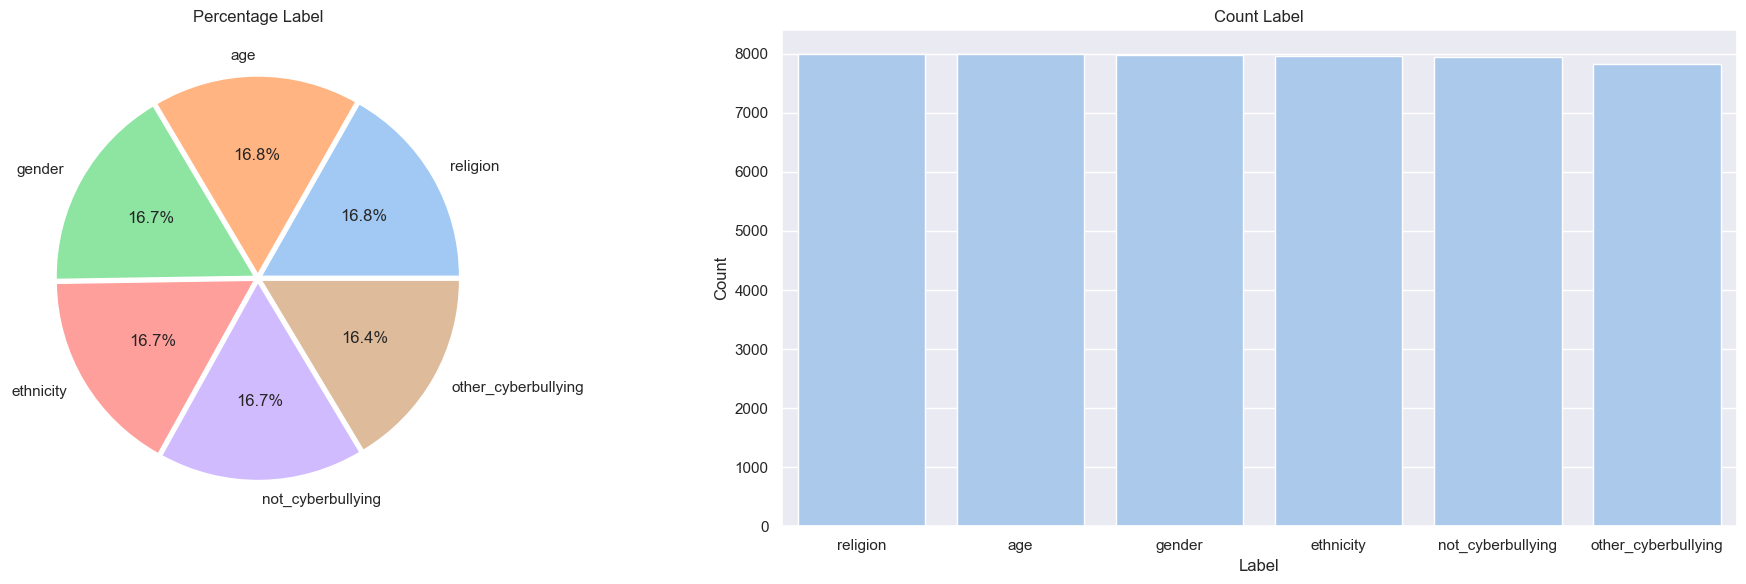

In [26]:
# Count occurrences of each label in 'cyberbullying_type' column
label_count = df['cyberbullying_type'].value_counts()

# Create subplots for pie chart and bar chart
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Set seaborn theme and palette
sb.set_theme(style='darkgrid', palette='pastel')

# Define colors and explode values for pie chart
color = sb.color_palette('pastel')
explode = [0.02] * len(label_count)

# Plot pie chart showing percentage of each label
axes[0].pie(label_count.values, labels=label_count.index, autopct='%1.1f%%', colors=color, explode=explode)
axes[0].set_title('Percentage Label')

# Plot bar chart showing count of each label
sb.barplot(x=label_count.index, y=label_count.values, ax=axes[1])
axes[1].set_title('Count Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

# Adjust layout to prevent overlapping of labels
plt.tight_layout()

# Display the plots
plt.show()

### Most Common Words by Tokenization
Here, we used tokenization to break down a piece of text like sentences or paragraphs into individual worlds or "tokens". From this plot, we can see the most common words in the tweets of our data.

In [27]:
from collections import Counter
import numpy as np

In [28]:
# Define a function to tokenize the text column
def Tokenize(column, seq_len):
    # Create a corpus of words from the text column
    corpus = [word for text in column for word in text.split()]

    # Count the occurrences of each word in the corpus
    count_words = Counter(corpus)

    # Sort words based on their frequencies
    sorted_words = count_words.most_common()

    # Assign unique integer indices to words
    vocab_to_int = {w: i + 1 for i, (w, c) in enumerate(sorted_words)}

    # Tokenize each text in the column using the vocabulary
    text_int = []
    for text in column:
        r = [vocab_to_int[word] for word in text.split()]
        text_int.append(r)

    # Pad/truncate sequences to match the specified sequence length
    features = np.zeros((len(text_int), seq_len), dtype=int)
    for i, review in enumerate(text_int):
        if len(review) <= seq_len:
            zeros = list(np.zeros(seq_len - len(review)))
            new = zeros + review
        else:
            new = review[: seq_len]
        features[i, :] = np.array(new)

    return sorted_words, features

#### Simple test of Tokenize Function

In [29]:
# Sample
sample_texts = [
    "you are stupid",
    "i hate you",
    "you are very stupid"
]

# Manually Count
corpus = []
for text in sample_texts:
    for word in text.split():
        corpus.append(word)

count_words = Counter(corpus)
sorted_words_manual = count_words.most_common()

print("Manual Sorted Words:")
print(sorted_words_manual)

# Manually map vocabulary
vocab_to_int_manual = {}
for i, (word, _) in enumerate(sorted_words_manual):
    vocab_to_int_manual[word] = i + 1

print("\nManual Vocab Mapping:")
print(vocab_to_int_manual)

# Manual tokenization
text_int_manual = []
for text in sample_texts:
    tokens = []
    for word in text.split():
        tokens.append(vocab_to_int_manual[word])
    text_int_manual.append(tokens)

# Manual Padding
seq_len = 5
features_manual = np.zeros((len(text_int_manual), seq_len), dtype=int)

for i, review in enumerate(text_int_manual):
    if len(review) <= seq_len:
        zeros = list(np.zeros(seq_len - len(review)))
        new = zeros + review
    else:
        new = review[:seq_len]
    features_manual[i, :] = np.array(new)

print("\nManual Tokenized & Padded Features:")
print(features_manual)

Manual Sorted Words:
[('you', 3), ('are', 2), ('stupid', 2), ('i', 1), ('hate', 1), ('very', 1)]

Manual Vocab Mapping:
{'you': 1, 'are': 2, 'stupid': 3, 'i': 4, 'hate': 5, 'very': 6}

Manual Tokenized & Padded Features:
[[0 0 1 2 3]
 [0 0 4 5 1]
 [0 1 2 6 3]]


In [30]:
# Test the function
sorted_words, features = Tokenize(sample_texts, seq_len=5)

print("\nSorted Words (by frequency):")
print(sorted_words)

print("\nTokenized & Padded Features:")
print(features)


Sorted Words (by frequency):
[('you', 3), ('are', 2), ('stupid', 2), ('i', 1), ('hate', 1), ('very', 1)]

Tokenized & Padded Features:
[[0 0 1 2 3]
 [0 0 4 5 1]
 [0 1 2 6 3]]


#### Apply Tokenizer Function

C:\Users\joshua\AppData\Local\Temp\ipykernel_2820\1045715215.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.barplot(x=keys, y=values, palette='mako')


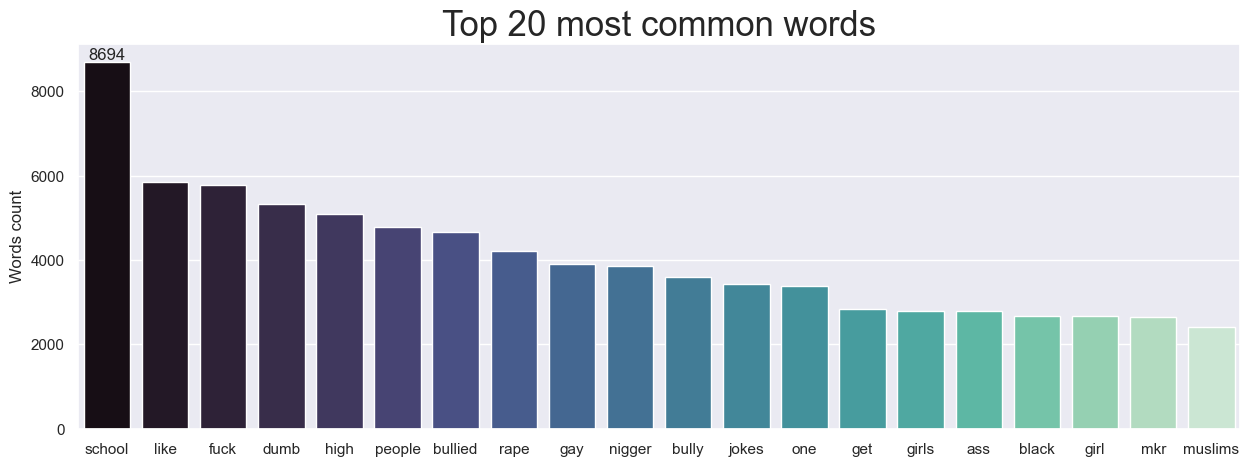

In [31]:
# Tokenize the tweet_clean column
vocabulary, tokenized_column = Tokenize(df["tweet_clean"], 300)

# Extract the top 20 most common words and their frequencies from the vocabulary
keys = []
values = []
for key, value in vocabulary[:20]:
    keys.append(key)
    values.append(value)

# Plotting the top 20 most common words
plt.figure(figsize=(15, 5))
ax = sb.barplot(x=keys, y=values, palette='mako')
plt.title('Top 20 most common words', size=25)
ax.bar_label(ax.containers[0])
plt.ylabel("Words count")
plt.show()

### Word Cloud
For this section, we used a WordCloud to present the most commonly seen words according to each classified category. The presence of each words in a tweet will increase its corresponding probability towards being classified into its respective category.

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#### Function to generating Word Cloud 

In [33]:
def word_cloud(data):
    # Filter text data for a specific cyberbullying type
    text = df[df['cyberbullying_type'] == data]

    # Concatenate all cleaned tweets into a single string
    text_cloud = " ".join(txt for txt in text['tweet_clean'])

    # Generate word cloud
    cloud = WordCloud(collocations=False, background_color='white').generate(text_cloud)

    # Display the word cloud
    plt.imshow(cloud)
    plt.axis('off')  # Hide axis

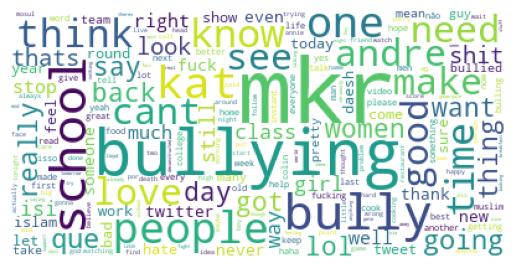

In [34]:
word_cloud('not_cyberbullying')

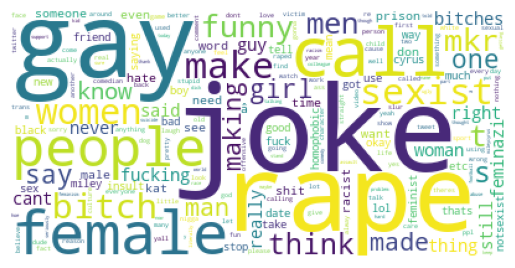

In [35]:

word_cloud('gender')

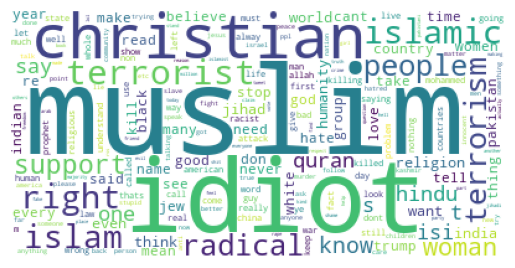

In [36]:
word_cloud('religion')

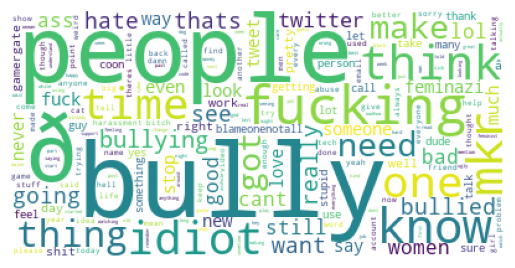

In [37]:
word_cloud('other_cyberbullying')

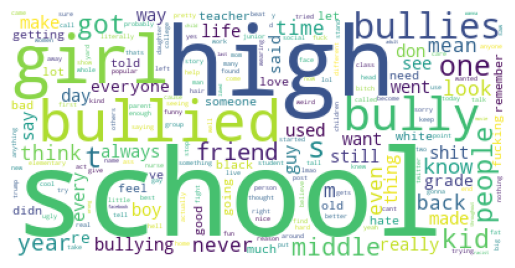

In [38]:
word_cloud('age')

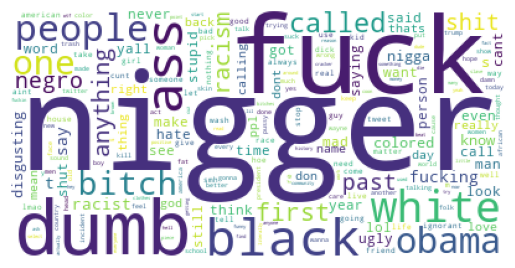

In [39]:
word_cloud('ethnicity')

### Sentiment Analysis
For sentiment analysis, we used the the module `TextBlob` for natural language processing tasks. The sentiment analysis model considers various factors such as: 

- word polarity
- intensity of sentiment
- context 

This is to determine the sentiment score for a given text. This would help us in identifying sentiments - positive, negative and neutral; from a piece of text.

The sentiment score represents the polarity of the text (Positive, Negative, Neutral). It is a floating point number ranging from -1.0 to +1.0.

> - If the sentiment score is close to 1.0, it indicates a very positive sentiment.
> - If the sentiment score is close to -1.0, it indicates a very negative sentiment.
> - If the sentiment score is around 0.0, it indicates a neutral sentiment.

In [40]:
from textblob import TextBlob

In [41]:
def analyze_sentiment(data):
    sentiments = []
    text = df[df['cyberbullying_type'] == data]
    # Concatenate cleaned tweets into a single string
    text_cloud = " ".join(txt for txt in text['tweet_clean'])
    # Iterate over cleaned tweets
    for tweet in text['tweet_clean']:
        blob = TextBlob(tweet)
        sentiment_score = abs(blob.sentiment.polarity)  # Get absolute value of sentiment polarity
        sentiments.append(sentiment_score)
    return sentiments

In [42]:
# Call the function for each cyberbullying type
not_cyberbullying = analyze_sentiment('not_cyberbullying')
gender = analyze_sentiment('gender')
religion = analyze_sentiment('religion')
other_cyberbullying = analyze_sentiment('other_cyberbullying')
age = analyze_sentiment('age')
ethnicity = analyze_sentiment('ethnicity')

# Print average sentiment scores for each type
print("Average sentiment score for cyberbullying tweets:", (sum(gender)+sum(religion)+sum(age)+sum(ethnicity)+sum(other_cyberbullying)) / (len(gender)+len(religion)+len(age)+len(ethnicity)+len(other_cyberbullying)))
print("Average sentiment score for not_cyberbullying tweets:", sum(not_cyberbullying) / len(not_cyberbullying))
print()
print("Average sentiment score for gender cyberbullying tweets:", sum(gender) / len(gender))
print("Average sentiment score for religion cyberbullying tweets:", sum(religion) / len(religion))
print("Average sentiment score for age cyberbullying tweets:", sum(age) / len(age))
print("Average sentiment score for ethnicity cyberbullying tweets:", sum(ethnicity) / len(ethnicity))
print("Average sentiment score for other_cyberbullying cyberbullying tweets:", sum(other_cyberbullying) / len(other_cyberbullying))

Average sentiment score for cyberbullying tweets: 0.23193334278478747
Average sentiment score for not_cyberbullying tweets: 0.18029953528919926

Average sentiment score for gender cyberbullying tweets: 0.2242584434469134
Average sentiment score for religion cyberbullying tweets: 0.23840078967838282
Average sentiment score for age cyberbullying tweets: 0.1746563899728508
Average sentiment score for ethnicity cyberbullying tweets: 0.27123820846987645
Average sentiment score for other_cyberbullying cyberbullying tweets: 0.2516593690304602


# Bi-LSTM Model Training

**Train-Test Split**

We split the data into train and test with the proportion 75:25

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score ,classification_report,confusion_matrix

x = df['tweet_clean']
y,class_names = pd.factorize(df['cyberbullying_type'],sort=True)

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=5)

x_train = [str(x) for x in X_train]
x_test  = [str(x) for x in X_test]

### What is Bi-LSTM?
LSTM (Long Short-Term Memory) is a renowned type of recurrent neural network (RNN) used for processing sequential data and capturing long-term dependencies. We employ Bidirectional-LSTM (Bi-LSTM) to extend this capability by processing input sequences in both forward and backward directions, effectively capturing contextual information.

### Architecture

The model architecture incorporates:

- An input embedding layer initialized with pre-trained word embeddings from Word2Vec, capturing the semantic meanings of tweets;

- A core LSTM layer, processing input sequences bidirectionally to capture nuanced relationships between words;

- An attention mechanism, focusing on important parts of the input sequence and enhancing the model's classification performance.

### Training Parameters

During training, the model parameters are optimized using the AdamW optimizer and minimize the negative log-likelihood loss function (NLLLoss). We define hyperparameters such as:

*Number of classes:* 6

*Hidden dimensions:* 100

*Number of LSTM layers:* 1

*Dropout rate*

*Learning rate*

*Number of epochs:* 10

Epochs refer to the number of times the entire dataset is passed forward and backward through the neural network during training. We implement early stopping based on validation accuracy to prevent overfitting.

### Model Evaluation

The best-performing model, based on validation accuracy, is selected for evaluation. After training, we evaluate the model on the test data and compute the classification report. The model achieves an accuracy of 0.81, demonstrating the effectiveness of our LSTM-based approach in cyberbullying tweet classification.

In [44]:
from gensim.models import Word2Vec

# Train Word2Vec model
Word2vec_train_data = list(map(lambda x: x.split(), x_train))
EMBEDDING_DIM = 200
word2vec_model = Word2Vec(Word2vec_train_data, vector_size=EMBEDDING_DIM)
print(f"Vocabulary size: {len(vocabulary) + 1}")

Vocabulary size: 53561


In [45]:
# Define a function to map sentiment labels to numerical values
df['sentiment'] = df['cyberbullying_type'].replace({
    'religion': 5,
    'age': 0,
    'ethnicity': 1,
    'gender': 2,
    'not_cyberbullying': 3,
    'other_cyberbullying': 4
})

# Define embedding matrix
VOCAB_SIZE = len(vocabulary) + 1
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

# Fill the embedding matrix with pre-trained values from word2vec
for word, token in vocabulary:
    if word in word2vec_model.wv.key_to_index:
        embedding_vector = word2vec_model.wv[word]
        embedding_matrix[token] = embedding_vector
print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (53561, 200)


In [57]:
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import RandomOverSampler
import torch

X = tokenized_column
y = df['sentiment'].values

print(X.shape)
print(y.shape)

print(np.unique(y), y.dtype)

(47692, 300)
(47692,)
[0 1 2 3 4 5] int8


In [64]:
df['sentiment'] = pd.Categorical(df['cyberbullying_type']).codes

# Optional: verify
print(np.unique(df['sentiment']), df['sentiment'].dtype)

X = tokenized_column.astype(np.int64)
y = df['sentiment'].astype(np.int64).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=5, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=5, stratify=y_train
)

ros = RandomOverSampler(random_state=5)
X_train_os, y_train_os = ros.fit_resample(X_train, y_train)

[0 1 2 3 4 5] int8


In [65]:
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import RandomOverSampler
import torch

X = tokenized_column
y = df['sentiment'].astype(np.int64).to_numpy()

# Split data into train, test, and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=5)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2)

# Apply Random Over Sampling
ros = RandomOverSampler()
X_train_os, y_train_os = ros.fit_resample(X_train, y_train)

# Convert data into PyTorch DataLoader
BATCH_SIZE = 32
train_data = TensorDataset(torch.from_numpy(X_train_os), torch.from_numpy(y_train_os))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
valid_data = TensorDataset(torch.from_numpy(X_valid), torch.from_numpy(y_valid))
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=False, batch_size=BATCH_SIZE, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE, drop_last=True)

In [66]:
import torch.nn as nn

# Define the Attention module
class Attention(nn.Module):
    def __init__(self, hidden_dim, is_bidirectional):
        super(Attention, self).__init__()
        self.is_bidirectional = is_bidirectional
        self.attn = nn.Linear(hidden_dim * (4 if is_bidirectional else 2), hidden_dim * (2 if is_bidirectional else 1))
        self.v = nn.Linear(hidden_dim * (2 if is_bidirectional else 1), 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        seq_len = encoder_outputs.size(1)
        if self.is_bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=-1)
        else:
            hidden = hidden[-1]
        hidden_repeated = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        attn_weights = torch.tanh(self.attn(torch.cat((hidden_repeated, encoder_outputs), dim=2)))
        attn_weights = self.v(attn_weights).squeeze(2)
        return nn.functional.softmax(attn_weights, dim=1)

# Define the LSTM Sentiment Classifier
class LSTM_Sentiment_Classifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, lstm_layers, dropout, is_bidirectional):
        super(LSTM_Sentiment_Classifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = lstm_layers
        self.is_bidirectional = is_bidirectional

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, lstm_layers, batch_first=True, bidirectional=is_bidirectional)
        self.attention = Attention(hidden_dim, is_bidirectional)
        self.fc = nn.Linear(hidden_dim * (2 if is_bidirectional else 1), num_classes)
        self.softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        out, hidden = self.lstm(embedded, hidden)
        attn_weights = self.attention(hidden[0], out)
        context = attn_weights.unsqueeze(1).bmm(out).squeeze(1)
        out = self.softmax(self.fc(context))
        return out, hidden

    def init_hidden(self, batch_size):
        factor = 2 if self.is_bidirectional else 1
        h0 = torch.zeros(self.num_layers * factor, batch_size, self.hidden_dim).to(DEVICE)
        c0 = torch.zeros(self.num_layers * factor, batch_size, self.hidden_dim).to(DEVICE)

In [67]:
NUM_CLASSES = 6
HIDDEN_DIM = 100
LSTM_LAYERS = 1
IS_BIDIRECTIONAL = False
LR = 4e-4
DROPOUT = 0.5
EPOCHS = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = LSTM_Sentiment_Classifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_CLASSES, LSTM_LAYERS, DROPOUT, IS_BIDIRECTIONAL)
model = model.to(DEVICE)

# Initialize the embedding layer with the previously defined embedding matrix
model.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
model.embedding.weight.requires_grad = True

# Set up the criterion (loss function) and optimizer
criterion = nn.NLLLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-6)
print(model)

LSTM_Sentiment_Classifier(
  (embedding): Embedding(53561, 200)
  (lstm): LSTM(200, 100, batch_first=True)
  (attention): Attention(
    (attn): Linear(in_features=200, out_features=100, bias=True)
    (v): Linear(in_features=100, out_features=1, bias=False)
  )
  (fc): Linear(in_features=100, out_features=6, bias=True)
  (softmax): LogSoftmax(dim=1)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
# Train the model
total_step = len(train_loader)
total_step_val = len(valid_loader)

early_stopping_patience = 4
early_stopping_counter = 0
valid_acc_max = 0

for e in range(EPOCHS):
    train_loss, valid_loss = [], []
    train_acc, valid_acc = [], []
    y_train_list, y_val_list = [], []
    correct, correct_val = 0, 0
    total, total_val = 0, 0
    running_loss, running_loss_val = 0, 0

    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        h = model.init_hidden(labels.size(0))
        model.zero_grad()
        output, h = model(inputs, h)
        loss = criterion(output, labels)
        loss.backward()
        running_loss += loss.item()
        optimizer.step()
        y_pred_train = torch.argmax(output, dim=1)
        y_train_list.extend(y_pred_train.squeeze().tolist())
        correct += torch.sum(y_pred_train == labels).item()
        total += labels.size(0)
    train_loss.append(running_loss / total_step)
    train_acc.append(100 * correct / total)

    with torch.no_grad():
        model.eval()
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            val_h = model.init_hidden(labels.size(0))
            output, val_h = model(inputs, val_h)
            val_loss = criterion(output, labels)
            running_loss_val += val_loss.item()
            y_pred_val = torch.argmax(output, dim=1)
            y_val_list.extend(y_pred_val.squeeze().tolist())
            correct_val += torch.sum(y_pred_val == labels).item()
            total_val += labels.size(0)
        valid_loss.append(running_loss_val / total_step_val)
        valid_acc.append(100 * correct_val / total_val)

    if np.mean(valid_acc) >= valid_acc_max:
        torch.save(model.state_dict(), './state_dict.pt')
        print(f'Epoch {e+1}:Validation accuracy increased ({valid_acc_max:.6f} --> {np.mean(valid_acc):.6f}).  Saving model ...')
        valid_acc_max = np.mean(valid_acc)
        early_stopping_counter = 0
    else:
        print(f'Epoch {e+1}:Validation accuracy did not increase')
        early_stopping_counter += 1

    if early_stopping_counter > early_stopping_patience:
        print('Early stopped at epoch :', e+1)
        break

    print(f'\tTrain_loss : {np.mean(train_loss):.4f} Val_loss : {np.mean(valid_loss):.4f}')
    print(f'\tTrain_acc : {np.mean(train_acc):.3f}% Val_acc : {np.mean(valid_acc):.3f}%')

Epoch 1:Validation accuracy increased (0.000000 --> 76.303251).  Saving model ...
	Train_loss : 0.8804 Val_loss : 0.5092
	Train_acc : 62.394% Val_acc : 76.303%
Epoch 2:Validation accuracy increased (76.303251 --> 79.848655).  Saving model ...
	Train_loss : 0.4387 Val_loss : 0.4680
	Train_acc : 80.143% Val_acc : 79.849%
Epoch 3:Validation accuracy increased (79.848655 --> 80.787556).  Saving model ...
	Train_loss : 0.3283 Val_loss : 0.4681
	Train_acc : 86.551% Val_acc : 80.788%
